<a href="https://colab.research.google.com/github/harshith2803/datamining/blob/main/Datamining.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
import pandas as pd
import re
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

In [8]:
df = pd.read_csv("Heart_Disease_Prediction.csv")
print(df)

     Age  Sex  Chest pain type   BP  Cholesterol  FBS over 120  EKG results  \
0     70    1                4  130          322             0            2   
1     67    0                3  115          564             0            2   
2     57    1                2  124          261             0            0   
3     64    1                4  128          263             0            0   
4     74    0                2  120          269             0            2   
..   ...  ...              ...  ...          ...           ...          ...   
265   52    1                3  172          199             1            0   
266   44    1                2  120          263             0            0   
267   56    0                2  140          294             0            2   
268   57    1                4  140          192             0            0   
269   67    1                4  160          286             0            2   

     Max HR  Exercise angina  ST depression  Slope 

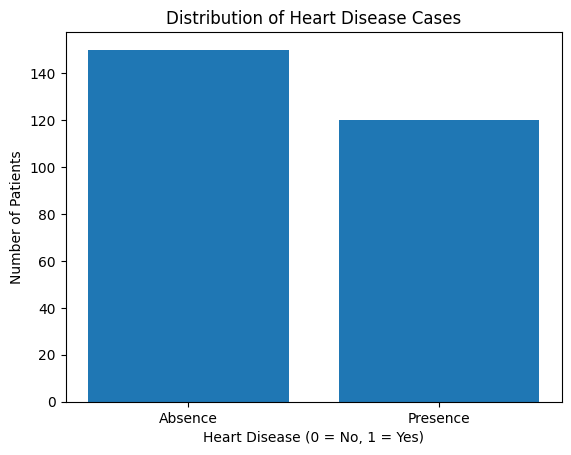

In [9]:
target_counts = df["Heart Disease"].value_counts()

# Create bar graph
plt.figure()
plt.bar(target_counts.index.astype(str), target_counts.values)

# Add labels
plt.xlabel("Heart Disease (0 = No, 1 = Yes)")
plt.ylabel("Number of Patients")
plt.title("Distribution of Heart Disease Cases")

# Show graph
plt.show()

In [10]:


df = pd.read_csv("Heart_Disease_Prediction.csv")


print("Original Shape:", df.shape)
print("\nMissing Values:\n", df.isnull().sum())

df = df.drop_duplicates()


num_cols = df.select_dtypes(include=['int64', 'float64']).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

# Fill categorical columns with mode
cat_cols = df.select_dtypes(include=['object']).columns
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

# Step 5: Verify cleaning
print("\nCleaned Shape:", df.shape)
print("\nRemaining Missing Values:\n", df.isnull().sum())

# Step 6: Save cleaned dataset
df.to_csv("Heart_Disease_Prediction_Cleaned.csv", index=False)

print("\nData Cleaning Completed Successfully!")

Original Shape: (270, 14)

Missing Values:
 Age                        0
Sex                        0
Chest pain type            0
BP                         0
Cholesterol                0
FBS over 120               0
EKG results                0
Max HR                     0
Exercise angina            0
ST depression              0
Slope of ST                0
Number of vessels fluro    0
Thallium                   0
Heart Disease              0
dtype: int64

Cleaned Shape: (270, 14)

Remaining Missing Values:
 Age                        0
Sex                        0
Chest pain type            0
BP                         0
Cholesterol                0
FBS over 120               0
EKG results                0
Max HR                     0
Exercise angina            0
ST depression              0
Slope of ST                0
Number of vessels fluro    0
Thallium                   0
Heart Disease              0
dtype: int64

Data Cleaning Completed Successfully!


In [11]:
X = df.drop("Heart Disease", axis=1)   # Change column name if different
y = df["Heart Disease"]

# Train-Test Split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Print shapes
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (216, 13)
X_test shape: (54, 13)
y_train shape: (216,)
y_test shape: (54,)


In [12]:
nb = MultinomialNB()
nb.fit(X_train, y_train)
nb_pred = nb.predict(X_test)
print("Naive Bayes Accuracy:", accuracy_score(y_test, nb_pred))

Naive Bayes Accuracy: 0.8333333333333334


In [13]:
svm = SVC(kernel='linear')
svm.fit(X_train, y_train)
svm_pred = svm.predict(X_test)
print("SVM Accuracy:", accuracy_score(y_test, svm_pred))

SVM Accuracy: 0.8703703703703703


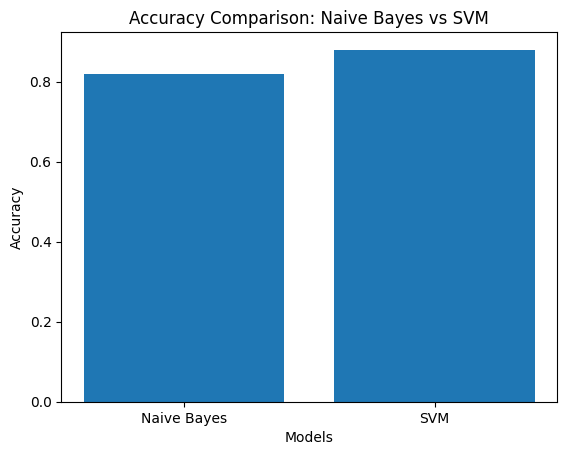

In [14]:
models = np.array(["Naive Bayes", "SVM"])

# Accuracy values (replace with your actual results)
accuracy = np.array([0.82, 0.88])

# Create bar graph
plt.figure()
plt.bar(models, accuracy)

# Add labels and title
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.title("Accuracy Comparison: Naive Bayes vs SVM")

# Display graph
plt.show()